# Evaluasi WER

In [1]:
import pandas as pd
import re

def clean_text_for_evaluation(text):
    """
    Membersihkan teks khusus untuk perhitungan evaluasi modifikasi kata.
    Mengubah teks menjadi huruf kecil dan menghapus semua tanda baca.
    """
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return " ".join(text.split())

def calculate_wer(reference, hypothesis):
    """
    Menghitung Word Error Rate (WER).
    """
    r_clean = clean_text_for_evaluation(reference)
    h_clean = clean_text_for_evaluation(hypothesis)
    
    r = r_clean.split()
    h = h_clean.split()
    
    d = [[0] * (len(h) + 1) for _ in range(len(r) + 1)]
    
    for i in range(len(r) + 1):
        d[i][0] = i
    for j in range(len(h) + 1):
        d[0][j] = j
        
    for i in range(1, len(r) + 1):
        for j in range(1, len(h) + 1):
            if r[i - 1] == h[j - 1]:
                cost = 0
            else:
                cost = 1
            
            d[i][j] = min(
                d[i - 1][j] + 1,      # Deletion
                d[i][j - 1] + 1,      # Insertion
                d[i - 1][j - 1] + cost # Substitution
            )
                          
    if len(r) == 0:
        return float('inf') if len(h) > 0 else 0.0
        
    return d[len(r)][len(h)] / len(r)

def evaluate_dataset_vs_threshold(csv_file, threshold=0.16):
    """
    Menghitung rata-rata tingkat perubahan kata (WER) untuk seluruh dataset
    dan membandingkannya dengan ambang batas (tau).
    """
    print(f"Membaca dataset dari '{csv_file}'...")
    df = pd.read_csv(csv_file)
    df = df.fillna("")
    
    print("Menghitung Tingkat Perubahan (WER) per baris...")
    
    # Menggabungkan teks mentah (raw) dan teks bersih (clean)
    df['text_raw_combined'] = df['findings_raw'] + " " + df['conclusion_raw']
    df['text_clean_combined'] = df['findings_clean'] + " " + df['conclusion_clean']
    
    # Menghitung metrik WER pada setiap baris
    df['tingkat_perubahan_wer'] = df.apply(
        lambda row: calculate_wer(row['text_raw_combined'], row['text_clean_combined']), axis=1
    )
    
    # Menghitung Rata-Rata Keseluruhan
    mean_wer_overall = df['tingkat_perubahan_wer'].mean()
    total_data = len(df)
    
    # Evaluasi Dataset terhadap Ambang Batas
    memenuhi_threshold = mean_wer_overall <= threshold
    status_evaluasi = "MEMENUHI" if memenuhi_threshold else "TIDAK MEMENUHI"
    
    print("\n" + "="*55)
    print("HASIL EVALUASI TINGKAT PERUBAHAN DATASET (WER)")
    print("="*55)
    print(f"Total Laporan Dievaluasi     : {total_data} laporan")
    print(f"Rata-rata Tingkat Perubahan  : {mean_wer_overall:.4f} ({mean_wer_overall*100:.2f}%)")
    print(f"Ambang Batas (Tau)           : <= {threshold} ({threshold*100:.0f}%)")
    print("-" * 55)
    print(f"Status Evaluasi Sistem       : {status_evaluasi} TARGET")
    print("="*55 + "\n")
    
    # Membersihkan kolom bantuan
    df = df.drop(columns=['text_raw_combined', 'text_clean_combined'])
    
    return df, mean_wer_overall, memenuhi_threshold

# ==========================================
# Cara Penggunaan / Eksekusi
# ==========================================
if __name__ == "__main__":
    FILE_PATH = 'normalized_dataset.csv' 
    TAU_THRESHOLD = 0.16  # Anda dapat mengubah angka ini sesuai standar toleransi yang Anda mau
    
    try:
        df_result, mean_wer, is_passed = evaluate_dataset_vs_threshold(FILE_PATH, threshold=TAU_THRESHOLD)
        
        # Menyimpan DataFrame beserta nilai WER per baris jika ingin diperiksa lebih lanjut
        output_file = 'evaluasi_wer_dataset.csv'
        df_result.to_csv(output_file, index=False)
        print(f"Detail perhitungan per baris disimpan ke '{output_file}'")
        
    except FileNotFoundError:
        print(f"Error: File '{FILE_PATH}' tidak ditemukan.")

Membaca dataset dari 'normalized_dataset.csv'...
Menghitung Tingkat Perubahan (WER) per baris...

HASIL EVALUASI TINGKAT PERUBAHAN DATASET (WER)
Total Laporan Dievaluasi     : 4019 laporan
Rata-rata Tingkat Perubahan  : 0.1581 (15.81%)
Ambang Batas (Tau)           : <= 0.16 (16%)
-------------------------------------------------------
Status Evaluasi Sistem       : MEMENUHI TARGET

Detail perhitungan per baris disimpan ke 'evaluasi_wer_dataset.csv'


# EVALUASI BERTSCORE

In [1]:
pip install bert-score pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /home/jovyan/work/TASI-106/my_kael/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from bert_score import score
import warnings

# Mengabaikan peringatan yang tidak perlu dari transformers
warnings.filterwarnings('ignore')

def evaluate_with_bertscore(csv_file):
    """
    Mengevaluasi hasil normalisasi teks radiologi menggunakan BERTScore.
    Metrik ini mengukur kemiripan makna (semantik) antara teks asli dan normalisasi.
    """
    print(f"Membaca dataset dari '{csv_file}'...")
    df = pd.read_csv(csv_file)
    df = df.fillna("")
    
    # Menggabungkan teks mentah (raw) dan teks bersih (clean) menjadi satu dokumen utuh
    df['text_raw_combined'] = df['findings_raw'] + " " + df['conclusion_raw']
    df['text_clean_combined'] = df['findings_clean'] + " " + df['conclusion_clean']
    
    # Menyiapkan list untuk input ke BERTScore
    # references = Teks Asli (Raw)
    # candidates = Teks Normalisasi (Clean)
    references = df['text_raw_combined'].tolist()
    candidates = df['text_clean_combined'].tolist()
    
    print("\nMenghitung BERTScore (Proses ini mungkin memakan waktu beberapa menit tergantung ukuran data)...")
    
    # Menghitung BERTScore
    # lang='id' akan otomatis menggunakan model multilingual-BERT yang mendukung Bahasa Indonesia
    # verbose=True untuk menampilkan progress bar
    P, R, F1 = score(
        cands=candidates, 
        refs=references, 
        lang="id", 
        verbose=True
    )
    
    # Menyimpan skor ke dalam DataFrame
    df['bert_precision'] = P.numpy()
    df['bert_recall'] = R.numpy()
    df['bert_f1'] = F1.numpy()
    
    # Menghitung rata-rata skor keseluruhan dataset
    mean_precision = df['bert_precision'].mean()
    mean_recall = df['bert_recall'].mean()
    mean_f1 = df['bert_f1'].mean()
    
    total_data = len(df)
    
    print("\n" + "="*55)
    print("HASIL EVALUASI SEMANTIK DENGAN BERTSCORE")
    print("="*55)
    print(f"Total Laporan Dievaluasi : {total_data} laporan")
    print("-" * 55)
    print(f"Rata-rata Precision      : {mean_precision:.4f} (Seberapa relevan teks normalisasi)")
    print(f"Rata-rata Recall         : {mean_recall:.4f} (Seberapa banyak makna asli yang dipertahankan)")
    print(f"Rata-rata F1-Score       : {mean_f1:.4f} (Skor keseimbangan/kemiripan keseluruhan)")
    print("="*55 + "\n")
    
    # Membersihkan kolom bantuan
    df = df.drop(columns=['text_raw_combined', 'text_clean_combined'])
    
    return df

# ==========================================
# Cara Penggunaan / Eksekusi
# ==========================================
if __name__ == "__main__":
    FILE_PATH = 'normalized_dataset.csv' 
    OUTPUT_FILE = 'evaluasi_bertscore_dataset.csv'
    
    try:
        # Jalankan evaluasi
        df_result = evaluate_with_bertscore(FILE_PATH)
        
        # Simpan hasil evaluasi
        df_result.to_csv(OUTPUT_FILE, index=False)
        print(f"Detail perhitungan BERTScore per baris telah disimpan ke '{OUTPUT_FILE}'")
        
        # (Opsional) Tampilkan 3 data dengan skor terendah untuk dianalisis
        print("\n3 Laporan dengan F1-Score BERT terendah (Untuk Pengecekan Halusinasi):")
        lowest_f1_df = df_result.sort_values(by='bert_f1', ascending=True).head(3)
        for i, (index, row) in enumerate(lowest_f1_df.iterrows(), 1):
            print(f"\n[Skor F1: {row['bert_f1']:.4f}]")
            print(f"Raw   : {row['findings_raw']} {row['conclusion_raw']}")
            print(f"Clean : {row['findings_clean']} {row['conclusion_clean']}")
            print("-" * 55)
            
    except FileNotFoundError:
        print(f"Error: File '{FILE_PATH}' tidak ditemukan.")
    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

/home/jovyan/work/TASI-106/my_kael/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Membaca dataset dari 'normalized_dataset.csv'...

Menghitung BERTScore (Proses ini mungkin memakan waktu beberapa menit tergantung ukuran data)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1038.73it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


100%|██████████| 60/60 [00:05<00:00, 11.37it/s]


computing greedy matching.


100%|██████████| 63/63 [00:02<00:00, 21.61it/s]


done in 8.27 seconds, 485.70 sentences/sec

HASIL EVALUASI SEMANTIK DENGAN BERTSCORE
Total Laporan Dievaluasi : 4019 laporan
-------------------------------------------------------
Rata-rata Precision      : 0.9080 (Seberapa relevan teks normalisasi)
Rata-rata Recall         : 0.9237 (Seberapa banyak makna asli yang dipertahankan)
Rata-rata F1-Score       : 0.9157 (Skor keseimbangan/kemiripan keseluruhan)

Detail perhitungan BERTScore per baris telah disimpan ke 'evaluasi_bertscore_dataset.csv'

3 Laporan dengan F1-Score BERT terendah (Untuk Pengecekan Halusinasi):

[Skor F1: 0.8233]
Raw   : Jantung tidak membesar, CTR <50 %. Aorta dan mediastinum superior tidak melebar. Trachea di tengah. Kedua hilus tidak menebal. Corakan bronchovaskuler kedua paru baik. Tampak area luscensi di lateral hemithoraks kanan. Tampak infiltrate di parenkim paru kanan. Sinus costophrenicus kanan tumpul. - Pneumothoraks dextra. - TB Paru aktif (DD/ Pneumonia). - Efusi pleura dextra.
Clean : Jantung tidak mem

In [3]:
import pandas as pd
import re
import warnings
from bert_score import score

# Mengabaikan peringatan yang tidak perlu dari pustaka transformers
warnings.filterwarnings('ignore')

def clean_text_for_evaluation(text):
    """
    Membersihkan teks dari tanda baca dan mengubahnya menjadi huruf kecil.
    Ini memastikan evaluasi semantik murni fokus pada kata-kata utamanya.
    """
    if pd.isna(text):
        return ""
    
    # 1. Ubah ke huruf kecil
    text = str(text).lower()
    
    # 2. Hapus tanda baca (hanya menyisakan huruf, angka, dan spasi)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # 3. Hapus spasi ganda yang mungkin muncul
    return " ".join(text.split())

def evaluate_bertscore_cleaned(csv_file):
    """
    Mengevaluasi hasil normalisasi menggunakan BERTScore pada teks yang 
    tanda baca dan kapitalisasinya sudah diabaikan/dibersihkan.
    """
    print(f"Membaca dataset dari '{csv_file}'...")
    df = pd.read_csv(csv_file)
    df = df.fillna("")
    
    print("Membersihkan teks (Menghapus tanda baca & kapitalisasi)...")
    
    # Menggabungkan teks mentah dan teks normalisasi per baris
    df['text_raw_combined'] = df['findings_raw'] + " " + df['conclusion_raw']
    df['text_clean_combined'] = df['findings_clean'] + " " + df['conclusion_clean']
    
    # Terapkan pembersihan teks SEBELUM dimasukkan ke BERTScore
    df['text_raw_cleaned'] = df['text_raw_combined'].apply(clean_text_for_evaluation)
    df['text_clean_cleaned'] = df['text_clean_combined'].apply(clean_text_for_evaluation)
    
    # Siapkan list untuk input model
    references = df['text_raw_cleaned'].tolist()
    candidates = df['text_clean_cleaned'].tolist()
    
    print("\nMenghitung BERTScore pada teks yang sudah dibersihkan...")
    print("(Proses ini mungkin memakan waktu beberapa saat)")
    
    # Menghitung BERTScore
    P, R, F1 = score(
        cands=candidates, 
        refs=references, 
        lang="id", 
        verbose=True
    )
    
    # Menyimpan skor ke DataFrame
    df['bert_precision'] = P.numpy()
    df['bert_recall'] = R.numpy()
    df['bert_f1'] = F1.numpy()
    
    # Ringkasan Evaluasi
    mean_precision = df['bert_precision'].mean()
    mean_recall = df['bert_recall'].mean()
    mean_f1 = df['bert_f1'].mean()
    total_data = len(df)
    
    print("\n" + "="*60)
    print("HASIL EVALUASI BERTSCORE (TANPA TANDA BACA & KAPITAL)")
    print("="*60)
    print(f"Total Laporan Dievaluasi : {total_data} laporan")
    print("-" * 60)
    print(f"Rata-rata Precision      : {mean_precision:.4f}")
    print(f"Rata-rata Recall         : {mean_recall:.4f}")
    print(f"Rata-rata F1-Score       : {mean_f1:.4f}")
    print("="*60 + "\n")
    
    # Hapus kolom bantuan agar rapi sebelum disimpan
    kolom_hapus = ['text_raw_combined', 'text_clean_combined', 'text_raw_cleaned', 'text_clean_cleaned']
    df = df.drop(columns=kolom_hapus)
    
    return df

# ==========================================
# Cara Penggunaan / Eksekusi
# ==========================================
if __name__ == "__main__":
    FILE_PATH = 'normalized_dataset.csv' 
    OUTPUT_FILE = 'evaluasi_bertscore_cleaned.csv'
    
    try:
        # Jalankan evaluasi dengan teks yang sudah dibersihkan
        df_result = evaluate_bertscore_cleaned(FILE_PATH)
        
        # Simpan hasilnya
        df_result.to_csv(OUTPUT_FILE, index=False)
        print(f"Detail skor per baris telah disimpan ke '{OUTPUT_FILE}'")
        
    except FileNotFoundError:
        print(f"Error: File '{FILE_PATH}' tidak ditemukan.")
    except Exception as e:
        print(f"Terjadi kesalahan saat menjalankan skrip: {e}")

Membaca dataset dari 'normalized_dataset.csv'...
Membersihkan teks (Menghapus tanda baca & kapitalisasi)...

Menghitung BERTScore pada teks yang sudah dibersihkan...
(Proses ini mungkin memakan waktu beberapa saat)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1867.29it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


100%|██████████| 58/58 [00:02<00:00, 21.74it/s]


computing greedy matching.


100%|██████████| 63/63 [00:00<00:00, 70.38it/s]


done in 3.58 seconds, 1123.71 sentences/sec

HASIL EVALUASI BERTSCORE (TANPA TANDA BACA & KAPITAL)
Total Laporan Dievaluasi : 4019 laporan
------------------------------------------------------------
Rata-rata Precision      : 0.9263
Rata-rata Recall         : 0.9373
Rata-rata F1-Score       : 0.9318

Detail skor per baris telah disimpan ke 'evaluasi_bertscore_cleaned.csv'


# EVALUASI Faithfulness Check

In [4]:
pip install transformers torch pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /home/jovyan/work/TASI-106/my_kael/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import torch
from transformers import pipeline
import warnings

warnings.filterwarnings('ignore')

def evaluate_faithfulness_nli(csv_file, batch_size=16):
    """
    Mengevaluasi Faithfulness teks menggunakan model Natural Language Inference (NLI).
    Mengukur probabilitas bahwa teks normalisasi (hypothesis) selaras (entailment) 
    dengan teks asli (premise).
    """
    print(f"Membaca dataset dari '{csv_file}'...")
    df = pd.read_csv(csv_file)
    df = df.fillna("")
    
    # Menggabungkan teks mentah (Premise) dan teks normalisasi (Hypothesis)
    df['premise'] = df['findings_raw'] + " " + df['conclusion_raw']
    df['hypothesis'] = df['findings_clean'] + " " + df['conclusion_clean']
    
    print("\nMemuat model NLI Multilingual...")
    # Menggunakan XLM-RoBERTa yang dilatih pada dataset XNLI (mendukung Bahasa Indonesia)
    # Model ini cocok untuk mendeteksi Entailment, Neutral, atau Contradiction
    model_name = "joeddav/xlm-roberta-large-xnli"
    
    device = 0 if torch.cuda.is_available() else -1
    nli_pipeline = pipeline("text-classification", model=model_name, device=device)
    
    print("Mulai menghitung Faithfulness Score (Entailment)...")
    print("Proses ini menggunakan komputasi yang lumayan berat, mohon tunggu...")
    
    faithfulness_scores = []
    labels = []
    
    # Memproses pasangan teks
    for idx, row in df.iterrows():
        # Format input untuk model NLI: "premise </s></s> hypothesis"
        text_pair = f"{row['premise']} </s></s> {row['hypothesis']}"
        
        try:
            # Truncate ke batas maksimal token model (512) jika teks terlalu panjang
            result = nli_pipeline(text_pair, truncation=True, max_length=512)[0]
            
            label = result['label']
            score = result['score']
            
            # Jika labelnya 'entailment', maka score adalah probabilitas entailment.
            # Jika label lain yang menang, kita anggap entailment prob-nya rendah 
            # (bisa diekstrak logits aslinya untuk akurasi lebih tinggi, tapi ini cukup untuk estimasi).
            if label == 'entailment':
                faithfulness_prob = score
            elif label == 'contradiction':
                faithfulness_prob = 1.0 - score
            else: # neutral
                faithfulness_prob = 0.5 
                
            labels.append(label)
            faithfulness_scores.append(faithfulness_prob)
            
        except Exception as e:
            print(f"Error pada indeks {idx}: {e}")
            labels.append("error")
            faithfulness_scores.append(0.0)
            
        # Tampilkan progress setiap 500 data
        if (idx + 1) % 500 == 0:
            print(f"[{idx + 1}/{len(df)}] data diproses...")
            
    df['nli_label'] = labels
    df['faithfulness_score'] = faithfulness_scores
    
    # Ringkasan Evaluasi
    mean_faithfulness = df['faithfulness_score'].mean()
    entailment_count = (df['nli_label'] == 'entailment').sum()
    contradiction_count = (df['nli_label'] == 'contradiction').sum()
    total_data = len(df)
    
    print("\n" + "="*65)
    print("HASIL EVALUASI FAITHFULNESS (NLI)")
    print("="*65)
    print(f"Total Laporan Dievaluasi     : {total_data} laporan")
    print(f"Rata-rata Faithfulness Score : {mean_faithfulness:.4f} (Mendekati 1.0 = Sangat Setia)")
    print("-" * 65)
    print(f"Jumlah Teks Entailment (Aman): {entailment_count} laporan")
    print(f"Jumlah Teks Contradiction    : {contradiction_count} laporan (PERLU DICEK MANUAL!)")
    print("="*65 + "\n")
    
    df = df.drop(columns=['premise', 'hypothesis'])
    return df

# ==========================================
# Cara Penggunaan / Eksekusi
# ==========================================
if __name__ == "__main__":
    FILE_PATH = 'normalized_dataset.csv' 
    OUTPUT_FILE = 'evaluasi_faithfulness_nli.csv'
    
    try:
        df_result = evaluate_faithfulness_nli(FILE_PATH)
        df_result.to_csv(OUTPUT_FILE, index=False)
        print(f"Detail evaluasi Faithfulness per baris telah disimpan ke '{OUTPUT_FILE}'")
        
        # Ekstrak otomatis sampel yang terindikasi kontradiksi (halusinasi)
        df_contradiction = df_result[df_result['nli_label'] == 'contradiction']
        if not df_contradiction.empty:
            df_contradiction.to_csv('sampel_kontradiksi_kritis.csv', index=False)
            print(f"PERINGATAN: Ditemukan {len(df_contradiction)} laporan yang berpotensi mengubah makna klinis.")
            print("Sampel ini dipisahkan ke 'sampel_kontradiksi_kritis.csv' untuk audit manual.")
            
    except FileNotFoundError:
        print(f"Error: File '{FILE_PATH}' tidak ditemukan.")

Membaca dataset dari 'normalized_dataset.csv'...

Memuat model NLI Multilingual...


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 1988.42it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Mulai menghitung Faithfulness Score (Entailment)...
Proses ini menggunakan komputasi yang lumayan berat, mohon tunggu...
[500/4019] data diproses...
[1000/4019] data diproses...
[1500/4019] data diproses...
[2000/4019] data diproses...
[2500/4019] data diproses...
[3000/4019] data diproses...
[3500/4019] data diproses...
[4000/4019] data diproses...

HASIL EVALUASI FAITHFULNESS (NLI)
Total Laporan Dievaluasi     : 4019 laporan
Rata-rata Faithfulness Score : 0.9829 (Mendekati 1.0 = Sangat Setia)
-----------------------------------------------------------------
Jumlah Teks Entailment (Aman): 3995 laporan
Jumlah Teks Contradiction    : 0 laporan (PERLU DICEK MANUAL!)

Detail evaluasi Faithfulness per baris telah disimpan ke 'evaluasi_faithfulness_nli.csv'


Memuat Processor dan Base Model: google/medgemma-4b-it...


Loading weights: 100%|██████████| 883/883 [00:01<00:00, 567.91it/s, Materializing param=model.vision_tower.vision_model.post_layernorm.weight]                       


Menempelkan LoRA Adapter dari: ../CODE FINE TUNE/medgemma-lora-adapter-final...
Menyiapkan gambar dan merakit prompt otomatis...

AI sedang menganalisis gambar...


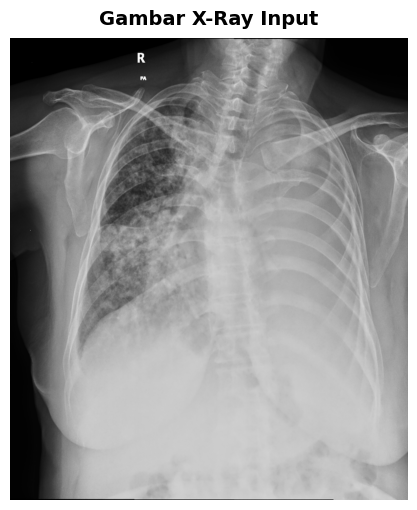

 🩺 HASIL DIAGNOSIS (Prompt: Apa temuan dan kesimpulan dari gambar thoraks berikut?)
Jantung tidak membesar. Aorta dan mediastinum superior tidak melebar. Trakea di tengah. Kedua hilus tidak menebal. Corakan bronkovaskuler kedua paru baik. Tidak tampak infiltrat di kedua lapangan paru. Kedua sinus kostofrenikus lancip, kedua hemidiafragma licin.

Kesimpulan:
Tidak tampak kelainan radiologis pada jantung dan paru-paru.


In [24]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM
from peft import PeftModel

# ==============================================================
# 1. PENGATURAN PATH (Sesuaikan dengan path di komputer Anda)
# ==============================================================
BASE_MODEL_ID = "google/medgemma-4b-it"       
ADAPTER_DIR = "../CODE FINE TUNE/medgemma-lora-adapter-final" # Ganti dengan folder LoRA terbaik Anda
IMAGE_PATH = "../PRE_TEXT/image_4019.png"       # Ganti dengan gambar X-Ray yang ingin dites

# ==============================================================
# 2. MEMUAT MODEL (MEDGEMMA + LORA)
# ==============================================================
print(f"Memuat Processor dan Base Model: {BASE_MODEL_ID}...")
processor = AutoProcessor.from_pretrained(BASE_MODEL_ID)

# Memuat model dasar
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

print(f"Menempelkan LoRA Adapter dari: {ADAPTER_DIR}...")
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model.eval() # Kunci model untuk mode inferensi

# ==============================================================
# 3. PERSIAPAN GAMBAR & PROMPT (MENGGUNAKAN CHAT TEMPLATE MUTLAK)
# ==============================================================
print("Menyiapkan gambar dan merakit prompt otomatis...")
raw_image = Image.open(IMAGE_PATH).convert("RGB")

# Tulis instruksi Anda di sini
instruksi_prompt = "Apa temuan dan kesimpulan dari gambar thoraks berikut?"

# Format pesan standar industri untuk Vision-Language Models
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"}, 
            {"type": "text", "text": instruksi_prompt}
        ]
    }
]

# Biarkan processor Hugging Face yang menerjemahkan jumlah token <image> yang tepat
prompt_final = processor.apply_chat_template(
    messages, 
    add_generation_prompt=True 
)

# Gabungkan gambar dan teks menjadi tensor yang siap dibaca GPU
inputs = processor(
    images=raw_image, 
    text=prompt_final, 
    return_tensors="pt"
).to(model.device)

# ==============================================================
# 4. EKSEKUSI INFERENSI
# ==============================================================
print("\nAI sedang menganalisis gambar...")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,
        temperature=0.0,
    )

# Memotong bagian instruksi agar murni mengambil jawaban AI saja
input_len = inputs["input_ids"].shape[1]
generated_tokens = outputs[0][input_len:]
hasil_diagnosis = processor.decode(generated_tokens, skip_special_tokens=True).strip()

# ==============================================================
# 5. TAMPILKAN HASIL (VISUAL & TEKS)
# ==============================================================
plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
plt.axis('off')
plt.title("Gambar X-Ray Input", fontsize=14, fontweight='bold', pad=10)
plt.show()

print("="*70)
print(f" 🩺 HASIL DIAGNOSIS (Prompt: {instruksi_prompt})")
print("="*70)
print(hasil_diagnosis)
print("="*70)